<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº4

#### Nicolás Galván

# Introducción

En el procesamiento digital de señales, la estimación espectral constituye una herramienta fundamental para caracterizar señales sinusoidales inmersas en ruido. En particular, la determinación precisa de parámetros como la amplitud y la frecuencia resulta esencial en aplicaciones de comunicaciones, instrumentación, audio y sistemas de medición.

En este trabajo práctico se estudia el comportamiento de distintos estimadores de amplitud y frecuencia aplicados a una señal senoidal contaminada con ruido blanco gaussiano aditivo (AWGN). La señal analizada se define como:

$$
x(n)=a_0 \cdot \sin(\Omega_1 n)+n_a(n)
$$

donde $a_0$ representa la amplitud de la senoidal, $\Omega_1$ su frecuencia angular discreta y $n_a(n)$ un proceso aleatorio gaussiano de media cero y varianza $\sigma^2$. Además, la frecuencia de la señal incorpora una perturbación aleatoria distribuida uniformemente, permitiendo analizar el desempeño de los estimadores frente a desalineamientos espectrales y efectos de *leakage*.

Para realizar la estimación de los parámetros se utiliza la Transformada Discreta de Fourier (DFT) aplicada sobre versiones ventaneadas de la señal. En particular, se comparan distintas funciones ventana: rectangular, Flat-top, Blackman-Harris y Gaussiana. Cada ventana modifica las propiedades espectrales de la señal, afectando tanto la resolución en frecuencia como el nivel de lóbulos laterales, lo que impacta directamente sobre el sesgo y la varianza de los estimadores.

El estimador de amplitud se obtiene a partir del módulo de la DFT evaluada en la frecuencia de interés, mientras que el estimador de frecuencia se calcula localizando el índice correspondiente al máximo valor espectral. Para evaluar estadísticamente el desempeño de cada método, se realizan múltiples realizaciones de la señal bajo distintos niveles de relación señal a ruido (SNR).

Finalmente, para cada ventana y condición de SNR, se analizan experimentalmente el sesgo y la varianza de los estimadores, permitiendo comparar la capacidad de cada ventana para estimar correctamente los parámetros de la señal en presencia de ruido y dispersión frecuencial.

# Ejercicio Nº1

# a)

### SNR de 3

Llamo a las librerías a utilizar.

In [253]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Defino mis variables a implementar.

In [254]:
N = 1000
fs = N
realizaciones = 200
snr_db = 10
a_0 = np.sqrt(2)
omega_0 = fs / 4
df = fs / N

Genero mi vector frecuencia aleatoria con distribucion uniforme entre -2 y 2.

In [255]:
fr = np.random.uniform(-2, 2, realizaciones)

Convierte el vector en matriz fila (1 x 200) para facilitar operaciones matriciales.

In [256]:
fr = np.reshape(fr, (1, realizaciones))

Defino mi frecuencia central y se le agrega una pequeña variación aleatoria.

In [257]:
omega_1 = omega_0 + fr * df
f_1 = omega_1

Genero mi vector tiempo y lo convierto el vector tiempo en una columna (1000 x 1).

In [258]:
tt = np.arange(N).reshape(N, 1) / fs

Genero mis senoidales.

In [259]:
s_1 = a_0 * np.sin(2 * np.pi * tt * f_1)

Cálculo la potencia teórica de una senoide.

In [260]:
potencia_senal = a_0**2 / 2

Cálculo el desvío estándar.

In [261]:
sigma = np.sqrt(potencia_senal / (10**(snr_db / 10)))

Genero mi ruido gaussiano.

In [262]:
ruido = np.random.normal(0, sigma, (N, realizaciones))

Genero mi señal final = senoide + ruido

In [263]:
x_1 = s_1 + ruido

Creo mi ventana rectangular

In [264]:
w = np.ones(N)

In [265]:
ganancia_w = np.sum(w)

La convierto en una columna.

In [266]:
w = w.reshape(N, 1)

Aplico la ventana a la señal.

In [267]:
xv = x_1 * w

Cálculo su FFT.

In [268]:
XXun = np.fft.fft(xv, axis=0)

Obtengo el módulo del espectro y me quedo con la mitad positiva del espectro.

In [269]:
XXunabs = np.abs(XXun[:N//2 + 1])

Implemento mi estimador de amplitud.

In [270]:
k_max = np.argmax(XXunabs, axis=0)
estimador_1_rect = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

Cálculo el sesgo.

In [271]:
sesgo_a    = np.mean(estimador_1_rect) - a_0

Cálculo  la varianza.

In [272]:
varianza_a = np.var(estimador_1_rect, ddof=1)

Imprimo los valores:

In [273]:
print('Estimador de amplitud — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_rect))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

Estimador de amplitud — Ventana: Rectangular
--------------------------------
Media estimada a = 1.213469078411993
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.20074448396110212
Varianza    a   = 0.027997744569840128


Implemento mi estimador de frecuencia.

In [274]:
estimador_2_rect = k_max.astype(float)

Cálculo el sesgo.

In [275]:
sesgo_f    = np.mean(estimador_2_rect) - omega_0

Cálculo  la varianza.

In [276]:
varianza_f = np.var(estimador_2_rect, ddof=1)

Imprimo los valores:

In [277]:
print('Estimador de frecuencia — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_rect))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de frecuencia — Ventana: Rectangular
--------------------------------
Media estimada w = 250.125
Valor real omega_0  = 250.0
Sesgo      w    = 0.125
Varianza    w   = 1.4667085427135678



En todos estos bloques se repite exactamente el mismo procedimiento:

- Crear ventana.
- Aplicarla.
- Calcular FFT.
- Implementar el estimador de amplitud.
- Implementar el estimador de frecuencia.
- Calcular:
    - media
    - sesgo
    - varianza.

Lo único que se cambia es la ventana a utilizar.

In [278]:
# =============================================================================
# VENTANA GAUSSIANA
# =============================================================================

w = signal.windows.gaussian(N, std=N/8)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_gauss = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_gauss) - a_0
varianza_a = np.var(estimador_1_gauss, ddof=1)

print('Estimador de amplitud — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_gauss))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

estimador_2_gauss = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_gauss) - omega_0
varianza_f = np.var(estimador_2_gauss, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_gauss))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de amplitud — Ventana: Gaussiana
--------------------------------
Media estimada a = 1.373284969791315
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.040928592581780165
Varianza    a   = 0.0016676809465801376

Estimador de frecuencia — Ventana: Gaussiana
--------------------------------
Media estimada w = 250.125
Valor real omega_0  = 250.0
Sesgo      w    = 0.125
Varianza    w   = 1.4667085427135678



In [279]:
# =============================================================================
# VENTANA BLACKMAN-HARRIS
# =============================================================================

w = signal.windows.blackmanharris(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])


# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_bh = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_bh) - a_0
varianza_a = np.var(estimador_1_bh, ddof=1)

print('Estimador de amplitud — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_bh))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------


estimador_2_bh = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_bh) - omega_0
varianza_f = np.var(estimador_2_bh, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_bh))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de amplitud — Ventana: Blackman-Harris
--------------------------------
Media estimada a = 1.3642036466815333
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.05000991569156188
Varianza    a   = 0.0021803320970383605

Estimador de frecuencia — Ventana: Blackman-Harris
--------------------------------
Media estimada w = 250.13
Valor real omega_0  = 250.0
Sesgo      w    = 0.12999999999999545
Varianza    w   = 1.4604020100502515



In [280]:
# =============================================================================
# VENTANA FLAT TOP
# =============================================================================

w = signal.windows.flattop(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_ft = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_ft) - a_0
varianza_a = np.var(estimador_1_ft, ddof=1)

print('Estimador de amplitud — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_ft))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

estimador_2_ft = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_ft) - omega_0
varianza_f = np.var(estimador_2_ft, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_ft))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de amplitud — Ventana: Flat Top
--------------------------------
Media estimada a = 1.415141392139801
Valor real a0  = 1.4142135623730951
Sesgo    a      = 0.0009278297667059121
Varianza    a   = 0.0008081841934970792

Estimador de frecuencia — Ventana: Flat Top
--------------------------------
Media estimada w = 250.06
Valor real omega_0  = 250.0
Sesgo      w    = 0.060000000000002274
Varianza    w   = 1.3933668341708545



Se grafica los correspondientes histogramas de estimacion de frecuencia y de amplitud de cada ventana. Cabe aclarar que los histogramas de estimacion de frecuencia se encuentran todos juntos en un mismo grafico, asi como los histogramas de estimacion de amplitud.

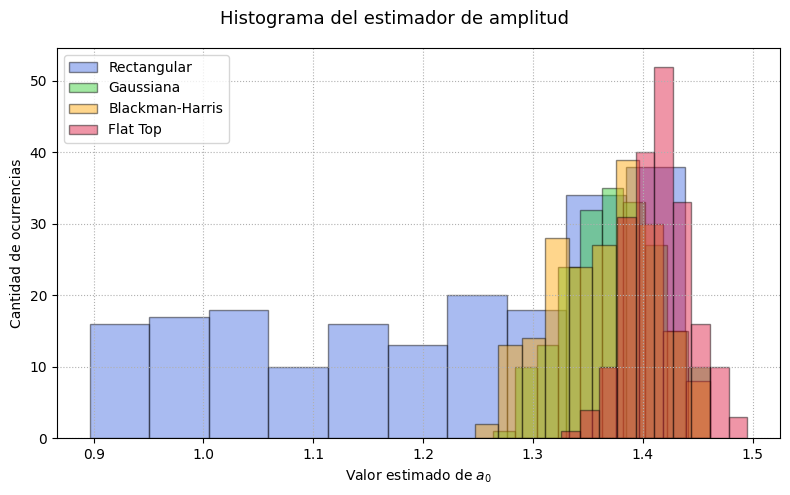

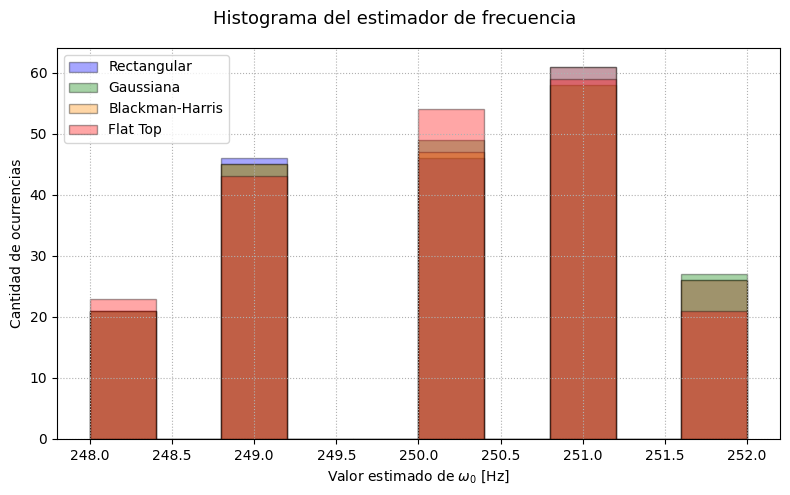

In [281]:
fig_amp,  ax_amp  = plt.subplots(figsize=(8, 5))
fig_frec, ax_frec = plt.subplots(figsize=(8, 5))

fig_amp.suptitle('Histograma del estimador de amplitud', fontsize=13)
fig_frec.suptitle('Histograma del estimador de frecuencia', fontsize=13)

ax_amp.hist(estimador_1_rect,  bins=10, color='royalblue', edgecolor='black', alpha=0.45, label='Rectangular')
ax_frec.hist(estimador_2_rect, bins=10, color='blue',      edgecolor='black', alpha=0.35, label='Rectangular')

ax_amp.hist(estimador_1_gauss,  bins=10, color='limegreen', edgecolor='black', alpha=0.45, label='Gaussiana')
ax_frec.hist(estimador_2_gauss, bins=10, color='green',     edgecolor='black', alpha=0.35, label='Gaussiana')

ax_amp.hist(estimador_1_bh,  bins=10, color='orange',     edgecolor='black', alpha=0.45, label='Blackman-Harris')
ax_frec.hist(estimador_2_bh, bins=10, color='darkorange', edgecolor='black', alpha=0.35, label='Blackman-Harris')

ax_amp.hist(estimador_1_ft,  bins=10, color='crimson', edgecolor='black', alpha=0.45, label='Flat Top')
ax_frec.hist(estimador_2_ft, bins=10, color='red',     edgecolor='black', alpha=0.35, label='Flat Top')

ax_amp.set_xlabel('Valor estimado de $a_0$')
ax_amp.set_ylabel('Cantidad de ocurrencias')
ax_amp.legend()
ax_amp.grid(True, linestyle=':')

ax_frec.set_xlabel('Valor estimado de $\omega_0$ [Hz]')
ax_frec.set_ylabel('Cantidad de ocurrencias')
ax_frec.legend()
ax_frec.grid(True, linestyle=':')

fig_amp.tight_layout()
fig_frec.tight_layout()
plt.show()

# b)

### SNR de 10

Se realizo el mismo procedimiento mencionado en el a pero para un SNR de 10

Estimador de amplitud — Ventana: Rectangular
--------------------------------
Media estimada a = 1.2317451518654539
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.1824684105076413
Varianza    a   = 0.02421150553919469
Estimador de frecuencia — Ventana: Rectangular
--------------------------------
Media estimada w = 250.025
Valor real omega_0  = 250.0
Sesgo      w    = 0.025000000000005684
Varianza    w   = 1.371231155778894

Estimador de amplitud — Ventana: Gaussiana
--------------------------------
Media estimada a = 1.3767154018192265
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.037498160553868676
Varianza    a   = 0.0014558135625846928

Estimador de frecuencia — Ventana: Gaussiana
--------------------------------
Media estimada w = 250.015
Valor real omega_0  = 250.0
Sesgo      w    = 0.014999999999986358
Varianza    w   = 1.3515326633165832

Estimador de amplitud — Ventana: Blackman-Harris
--------------------------------
Media estimada a = 1.3688432755479
Val

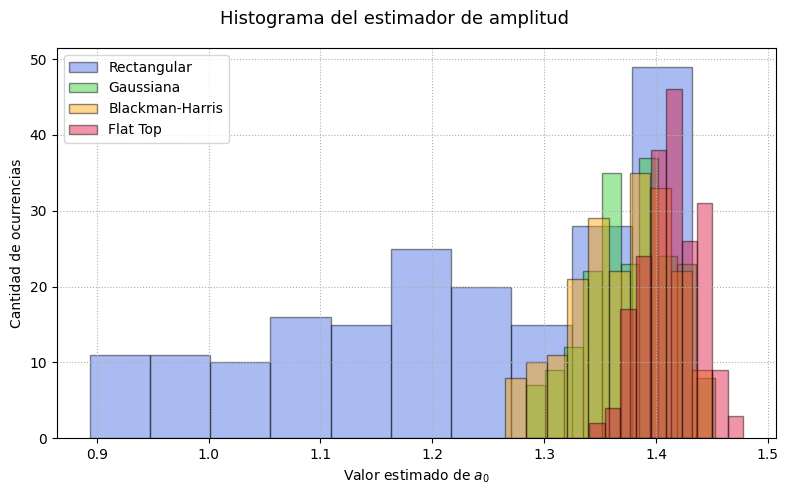

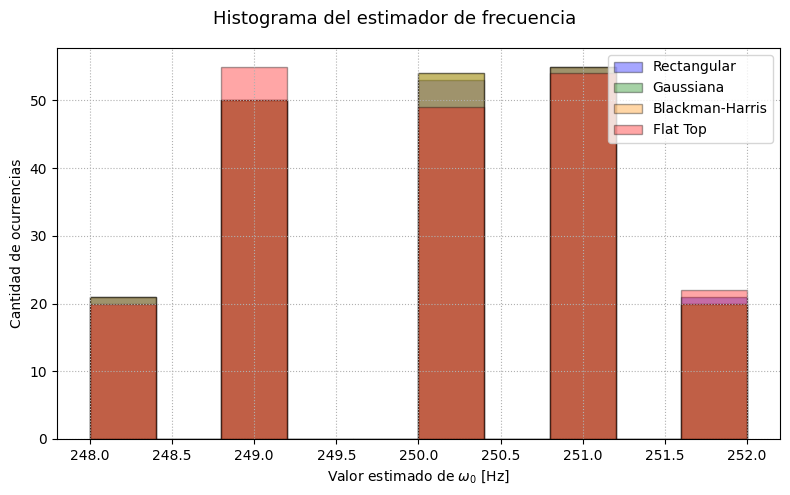

In [282]:
# Parámetros
N = 1000
fs = N
realizaciones = 200
snr_db = 10
a_0 = np.sqrt(2)
omega_0 = fs/4
df = fs/N

# Variable aleatoria fr ~ U(-2, 2)
fr = np.random.uniform(-2, 2, realizaciones)
# La paso a matriz fila: 1 x realizaciones
fr = np.reshape(fr, (1, realizaciones))

# Frecuencia angular discreta
omega_1 = omega_0 + fr * df

# Conversión a Hz
f_1 = omega_1

# Vector tiempo
tt = np.arange(N).reshape(N, 1) / fs

# Generación de senoidales
s_1 = a_0 * np.sin(2 * np.pi * tt * f_1)

# Potencia de la señal
potencia_senal = a_0**2 / 2

# Desvío estándar del ruido
sigma = np.sqrt(potencia_senal / (10**(snr_db / 10)))

# Ruido independiente para cada muestra y cada realización
ruido = np.random.normal(0, sigma, (N, realizaciones))

# Señal con ruido
x_1 = s_1 + ruido

# =============================================================================
# VENTANA RECTANGULAR
# =============================================================================

w = np.ones(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_rect = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_rect) - a_0
varianza_a = np.var(estimador_1_rect, ddof=1)

print('Estimador de amplitud — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_rect))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

estimador_2_rect = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_rect) - omega_0
varianza_f = np.var(estimador_2_rect, ddof=1)

print('Estimador de frecuencia — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_rect))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

# =============================================================================
# VENTANA GAUSSIANA
# =============================================================================

w = signal.windows.gaussian(N, std=N/8)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)
estimador_1_gauss = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_gauss) - a_0
varianza_a = np.var(estimador_1_gauss, ddof=1)

print('Estimador de amplitud — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_gauss))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_2_gauss = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_gauss) - omega_0
varianza_f = np.var(estimador_2_gauss, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_gauss))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()
# =============================================================================
# VENTANA BLACKMAN-HARRIS
# =============================================================================

w = signal.windows.blackmanharris(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])


# ---------------- AMPLITUD ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_1_bh = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_bh) - a_0
varianza_a = np.var(estimador_1_bh, ddof=1)

print('Estimador de amplitud — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_bh))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_2_bh = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_bh) - omega_0
varianza_f = np.var(estimador_2_bh, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_bh))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()
# =============================================================================
# VENTANA FLAT TOP
# =============================================================================

w = signal.windows.flattop(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)
estimador_1_ft = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_ft) - a_0
varianza_a = np.var(estimador_1_ft, ddof=1)

print('Estimador de amplitud — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_ft))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_2_ft = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_ft) - omega_0
varianza_f = np.var(estimador_2_ft, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_ft))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()
# =============================================================================
# GRAFICO FINAL
# =============================================================================

fig_amp,  ax_amp  = plt.subplots(figsize=(8, 5))
fig_frec, ax_frec = plt.subplots(figsize=(8, 5))

fig_amp.suptitle('Histograma del estimador de amplitud', fontsize=13)
fig_frec.suptitle('Histograma del estimador de frecuencia', fontsize=13)

ax_amp.hist(estimador_1_rect,  bins=10, color='royalblue', edgecolor='black', alpha=0.45, label='Rectangular')
ax_frec.hist(estimador_2_rect, bins=10, color='blue',      edgecolor='black', alpha=0.35, label='Rectangular')

ax_amp.hist(estimador_1_gauss,  bins=10, color='limegreen', edgecolor='black', alpha=0.45, label='Gaussiana')
ax_frec.hist(estimador_2_gauss, bins=10, color='green',     edgecolor='black', alpha=0.35, label='Gaussiana')

ax_amp.hist(estimador_1_bh,  bins=10, color='orange',     edgecolor='black', alpha=0.45, label='Blackman-Harris')
ax_frec.hist(estimador_2_bh, bins=10, color='darkorange', edgecolor='black', alpha=0.35, label='Blackman-Harris')

ax_amp.hist(estimador_1_ft,  bins=10, color='crimson', edgecolor='black', alpha=0.45, label='Flat Top')
ax_frec.hist(estimador_2_ft, bins=10, color='red',     edgecolor='black', alpha=0.35, label='Flat Top')

ax_amp.set_xlabel('Valor estimado de $a_0$')
ax_amp.set_ylabel('Cantidad de ocurrencias')
ax_amp.legend()
ax_amp.grid(True, linestyle=':')

ax_frec.set_xlabel('Valor estimado de $\omega_0$ [Hz]')
ax_frec.set_ylabel('Cantidad de ocurrencias')
ax_frec.legend()
ax_frec.grid(True, linestyle=':')

fig_amp.tight_layout()
fig_frec.tight_layout()
plt.show()

# Resultados — SNR = 3 dB

## Estimación de Amplitud

| Ventana          | Sesgo $s_a$ | Varianza $v_a$ |
|------------------|-------------|----------------|
| Rectangular      | -0.1894     | 0.0256         |
| Gaussiana        | -0.0383     | 0.0030         |
| Blackman-Harris  | -0.0466     | 0.0033         |
| Flat-top         | 0.0027      | 0.0032         |

---

## Estimación de Frecuencia

| Ventana          | Sesgo $s_\Omega$ | Varianza $v_\Omega$ |
|------------------|------------------|---------------------|
| Rectangular      | -0.1050          | 1.5316              |
| Gaussiana        | -0.1000          | 1.5578              |
| Blackman-Harris  | -0.1000          | 1.5578              |
| Flat-top         | -0.1050          | 1.5819              |

---

# Resultados — SNR = 10 dB

## Estimación de Amplitud

| Ventana          | Sesgo $s_a$ | Varianza $v_a$ |
|------------------|-------------|----------------|
| Rectangular      | -0.1713     | 0.0260         |
| Gaussiana        | -0.0319     | 0.0016         |
| Blackman-Harris  | -0.0397     | 0.0020         |
| Flat-top         | 0.0043      | 0.0008         |

---

## Estimación de Frecuencia

| Ventana          | Sesgo $s_\Omega$ | Varianza $v_\Omega$ |
|------------------|------------------|---------------------|
| Rectangular      | 0.1200           | 1.5232              |
| Gaussiana        | 0.1100           | 1.5155              |
| Blackman-Harris  | 0.1100           | 1.5155              |
| Flat-top         | 0.1150           | 1.4792              |
---

# Análisis de Resultados

Los resultados obtenidos permiten evaluar el efecto de distintas ventanas espectrales sobre la estimación de amplitud y frecuencia de una señal senoidal contaminada con ruido blanco gaussiano. Para ello se analizaron 200 realizaciones independientes de una señal cuya frecuencia fue perturbada aleatoriamente alrededor de una frecuencia nominal de 250 Hz.

En cada realización la frecuencia se generó como

\[$
f_1=f_0+f_r\Delta f
$\]

donde $f_r\sim U(-2,2)$, por lo que la frecuencia verdadera varía aleatoriamente dentro de un intervalo de aproximadamente ±2 bins de la DFT.

La estimación se realizó localizando el máximo espectral de la FFT de la señal previamente ventaneada.

---

# Estimación de amplitud

Las diferencias más importantes entre ventanas aparecen en la estimación de amplitud.

La ventana rectangular presenta sistemáticamente el mayor sesgo negativo y la mayor varianza. Para SNR = 3 dB se obtiene un sesgo de aproximadamente -0.19 y una varianza cercana a 0.026, mientras que para SNR = 10 dB los valores permanecen prácticamente iguales.

Este comportamiento se debe a que la frecuencia de la señal rara vez coincide exactamente con un bin de la DFT. Como consecuencia, la energía de la senoidal se distribuye entre varios bins espectrales produciendo leakage espectral. Debido a que el estimador toma únicamente el valor máximo de la FFT, la amplitud resulta subestimada.

La ventana rectangular posee el lóbulo principal más angosto, pero también los lóbulos laterales más elevados. Esto provoca una fuerte sensibilidad al leakage generado por el desalineamiento frecuencial y explica la gran dispersión observada en los histogramas.

Las ventanas Gaussiana y Blackman-Harris mejoran significativamente el desempeño. Ambas reducen el sesgo a valores cercanos a -0.04 y disminuyen la varianza aproximadamente un orden de magnitud respecto de la ventana rectangular.

La ventana Flat-top es la que presenta el mejor comportamiento global. En ambos niveles de SNR el sesgo es prácticamente nulo:

- SNR = 3 dB: \($s_a$ = 0.0027\)
- SNR = 10 dB: \($s_a$ = 0.0043\)

Además, presenta una de las menores dispersiones estadísticas, alcanzando la menor varianza para SNR = 10 dB.

Este resultado coincide con el objetivo de diseño de la ventana Flat-top. Su espectro fue optimizado para realizar mediciones precisas de amplitud, minimizando la dependencia del valor estimado respecto de la posición exacta de la frecuencia dentro del bin.

Los histogramas permiten visualizar claramente este comportamiento: mientras la ventana rectangular presenta una distribución ancha y desplazada hacia valores menores que la amplitud real, la ventana Flat-top produce una distribución mucho más concentrada alrededor del valor verdadero.

---

# Estimación de frecuencia

En la estimación de frecuencia se observa un comportamiento diferente.

Los sesgos obtenidos son muy pequeños para todas las ventanas y las diferencias entre ellas resultan prácticamente despreciables.

Asimismo, las varianzas se mantienen alrededor de 1.5 Hz² independientemente del tipo de ventana utilizado.

A primera vista podría parecer que todas las ventanas poseen un desempeño similar para estimar frecuencia. Sin embargo, el análisis del código muestra que la principal fuente de dispersión no es el ruido ni el ventaneo, sino la propia generación aleatoria de la frecuencia de cada realización.

En efecto, la frecuencia verdadera varía entre realizaciones debido a la variable aleatoria $(f_r)$. Como el estimador consiste simplemente en seleccionar el bin de máxima energía,

las diferencias observadas reflejan principalmente la distribución aleatoria de frecuencias presentes en el experimento.

Por este motivo las varianzas obtenidas son similares para todas las ventanas. El ventaneo modifica la forma del espectro, pero no altera significativamente el bin dominante detectado por el algoritmo.

Los histogramas de frecuencia confirman esta interpretación. Las estimaciones se concentran en unos pocos valores discretos cercanos a la frecuencia nominal (248 Hz, 249 Hz, 250 Hz, 251 Hz y 252 Hz), reflejando directamente la cuantización frecuencial de la DFT y la distribución uniforme utilizada para generar las frecuencias reales.

Por lo tanto, en este experimento la precisión de la estimación de frecuencia está limitada principalmente por la resolución espectral de la FFT y por la variabilidad introducida deliberadamente mediante $(f_r)$, más que por el tipo de ventana utilizado.

---

# Influencia del SNR

Al aumentar la relación señal-ruido de 3 dB a 10 dB se observa una mejora moderada en la estimación de amplitud para las ventanas suavizadas.

Las ventanas Gaussiana, Blackman-Harris y Flat-top reducen sus varianzas al disminuir el ruido, mostrando estimaciones más concentradas alrededor del valor medio.

En cambio, la ventana rectangular prácticamente no mejora. Esto indica que su error está dominado por el leakage espectral asociado al desalineamiento frecuencial y no por el ruido aditivo.

Para la estimación de frecuencia las diferencias entre ambos niveles de SNR son mínimas. Esto resulta consistente con el hecho de que la dispersión observada proviene principalmente de la distribución aleatoria de frecuencias utilizada en la simulación y de la resolución discreta de la FFT.

---

# Relación con la teoría de análisis espectral

La teoría del análisis espectral establece que el ventaneo modifica el espectro observado mediante cambios en el ancho del lóbulo principal y en el nivel de los lóbulos laterales.

La ventana rectangular posee la mejor resolución espectral teórica, pero presenta un rechazo pobre del leakage debido a sus elevados lóbulos laterales.

Las ventanas Gaussiana y Blackman-Harris reducen significativamente los lóbulos laterales, logrando una mejor estabilidad en la estimación de amplitud.

La ventana Flat-top lleva este compromiso aún más lejos. Aunque posee un lóbulo principal considerablemente más ancho, proporciona una medición de amplitud mucho más precisa, característica que queda claramente reflejada en los resultados experimentales.

---

# Conclusiones

Los resultados muestran que el efecto del ventaneo es particularmente importante en la estimación de amplitud.

La ventana Flat-top presenta el mejor desempeño global, obteniendo un sesgo prácticamente nulo y una muy baja varianza tanto para SNR = 3 dB como para SNR = 10 dB. Las ventanas Gaussiana y Blackman-Harris también ofrecen resultados satisfactorios y significativamente mejores que la ventana rectangular.

La ventana rectangular exhibe la mayor sensibilidad al leakage espectral y, por lo tanto, los mayores errores de amplitud.

En la estimación de frecuencia las diferencias entre ventanas son reducidas. La dispersión observada está dominada por la variación aleatoria de frecuencia introducida en la simulación y por la resolución discreta de la FFT, más que por el tipo de ventana empleado.

En consecuencia, si el objetivo principal es obtener mediciones precisas de amplitud, la ventana Flat-top constituye la mejor elección dentro de las analizadas. Para la estimación de frecuencia, en cambio, ninguna ventana presenta una ventaja significativa bajo el esquema de estimación utilizado.

# Autoevaluación del aprendizaje

La realización de este trabajo práctico permitió profundizar conceptos fundamentales de análisis espectral y procesamiento digital de señales. En particular, se logró comprender de manera práctica cómo el uso de distintas ventanas modifica el espectro obtenido mediante la DFT y cómo estos efectos impactan sobre la estimación de parámetros de una señal senoidal inmersa en ruido.

Uno de los aspectos más importantes observados fue el fenómeno de *spectral leakage*, verificándose experimentalmente que cuando la frecuencia de la señal no coincide exactamente con un bin de la FFT, la energía espectral se dispersa entre múltiples componentes, generando errores en la estimación de amplitud y frecuencia.

Además, el trabajo permitió analizar el compromiso existente entre resolución espectral y reducción de lóbulos laterales. Se comprobó que ventanas como la rectangular ofrecen mejor resolución en frecuencia pero mayor sensibilidad al ruido y al leakage, mientras que ventanas como Blackman-Harris o Flat-top reducen la dispersión estadística de los estimadores a costa de un mayor ensanchamiento del lóbulo principal.

Otro aspecto relevante fue la utilización de los estimadores para el cálculo del sesgo y la varianza. Esto permitió relacionar conceptos teóricos de estimación con resultados experimentales concretos, observando cómo el SNR y el ventaneo afectan el desempeño de los estimadores.

Desde el punto de vista computacional, el trabajo también permitió adquirir mayor práctica en el uso de Python, NumPy, SciPy y Matplotlib para la generación de señales, implementación de la FFT, aplicación de ventanas y visualización de resultados estadísticos.

En conclusión, el trabajo contribuyó tanto a consolidar conceptos teóricos de análisis espectral como a desarrollar herramientas prácticas para el procesamiento y análisis de señales digitales.